In [102]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig
import sys
sys.path.append('/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/L5PC_neuron')
from common_function import exp_fitting, plot_curve

# passive case

Text(0, 0.5, 'Voltage (mV)')

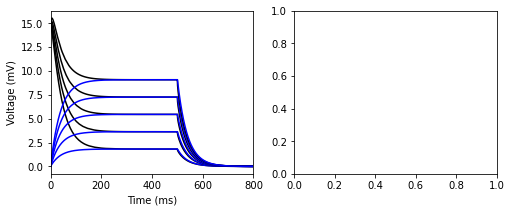

In [103]:
data = np.loadtxt('pas_parameter_neuron_passive.dat')
dt=0.1
tstop=1000
t=np.arange(0,tstop+dt,dt)
v_rest = np.mean(data[:,-1])
v_norm = data[:,1:] - v_rest
I = np.arange(0.01,0.06,0.01)*1e-3
gl = np.zeros((5,1))
c = np.zeros((5,1))
        
def verfication(GL, C, t, I):
    
    v = np.zeros(len(t))
    for i in range(len(t)-1):
        v[i+1] = v[i] + dt/C*(-GL*v[i]+I[i])
        
    return v
# print(np.shape(I))
fig, ax2 = plt.subplots(1,2, figsize = (8,3))
for i in range(5):
    gl[i] = I[i]/v_norm[i,4000]
    y = np.log(v_norm[i, 5001:6001])
    A = np.ones((len(t[5001:6001]),2))
    A[:,0] = t[5001:6001] - t[5001]
    # print(np.shape(A))
    # print(np.shape(y))
    x, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
    tau_decay = -1./x[0] 
    c[i] = tau_decay*gl[i]
    input = np.ones(len(t))*I[i]
    input[5001:] = 0.
    v_pred = verfication(gl[i], c[i], t, input)
    ax2[0].plot(t,v_norm[i,:],'k')
    ax2[0].plot(t,v_pred,'b')
    ax2[0].set_xlim([0,800])
ax2[0].set_xlabel('Time (ms)')
ax2[0].set_ylabel('Voltage (mV)')   

# point neuron -- somatic synapse

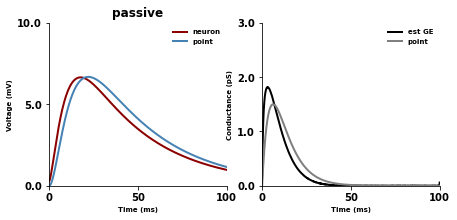

In [109]:
data = np.loadtxt('pair_EI_VClamp_REV80_passive.dat')
V_neuron = data[0,:] - v_rest
time = np.arange(0,len(V_neuron))*0.1
V = np.zeros(len(V_neuron))
gl0 = np.mean(gl)*0.92
c0 = np.mean(c)*0.92
REV_E = 0. - v_rest
fE = 1.5e-3
NE = ((5./7.8)**(5./2.8)-(5./7.8)**(7.8/2.8))**(-1)
uE = np.exp(-time/7.8)-np.exp(-time/5.)


fig,ax = plt.subplots(1,2, figsize = (7,3))
dVdt = np.diff(V_neuron)/dt
dVdt = np.append(dVdt,0)
GE_est = (c0*dVdt + gl0*V_neuron)/(REV_E-V_neuron) 


for i in range(len(V_neuron)-1):
    V[i+1]=V[i]-(gl0*V[i]-fE*NE*uE[i]*1e-3*(REV_E-V[i]))*dt/c0
plot_curve(ax[0],time[2000:]-200, V_neuron[2000:],label = 'neuron',color='darkred',
    ylabel='Voltage (mV)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,10], dy = 5.)
plot_curve(ax[0],time,V,label = 'point',color='steelblue',
    ylabel='Voltage (mV)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,10], dy = 5., title='passive')

plot_curve(ax[1],time[2000:]-200, GE_est[2000:]*1e6,label = 'est GE',color='black',
    ylabel='Conductance (pS)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,2], dy = 1.)
plot_curve(ax[1],time,fE*NE*uE*1e3,label = 'point',color='grey',
    ylabel='Conductance (pS)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,3], dy = 1.)



## active case

Text(0.5, 1.0, 'Li')

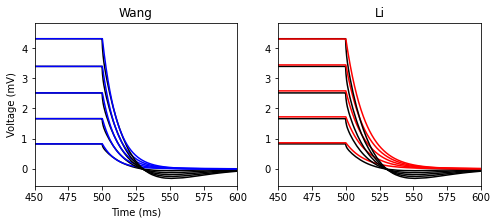

In [119]:
data = np.loadtxt('pas_parameter_neuron_active.dat')
dt=0.1
tstop=1000
t=np.arange(0,tstop+dt,dt)
v_rest = np.mean(data[:,-1])
v_norm = data[:,1:] - v_rest
I = np.arange(0.01,0.06,0.01)*1e-3
gl = np.zeros((5,1))
c = np.zeros((5,1))
        
def verfication(GL, C, t, I):
    
    v = np.zeros(len(t))
    for i in range(len(t)-1):
        v[i+1] = v[i] + dt/C*(-GL*v[i]+I[i])
        
    return v

GL = 0.07;   
S = 1.66e-4;  
# print(np.shape(I))
fig, ax2 = plt.subplots(1,2, figsize = (8,3))
for i in range(5):
    gl[i] = I[i]/v_norm[i,4000]
    y = np.log(v_norm[i, 5001:5201])
    A = np.ones((len(t[5001:5201]),2))
    A[:,0] = t[5001:5201] - t[5001]
    # print(np.shape(A))
    # print(np.shape(y))
    x, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
    tau_decay = -1./x[0] 
    c[i] = tau_decay*gl[i]
    input = np.ones(len(t))*I[i]
    input[5001:] = 0.
    v_pred = verfication(gl[i], c[i], t, input)
    v_pred_li = verfication(GL*S, S, t, input)
    ax2[0].plot(t,v_norm[i,:],'k')
    ax2[1].plot(t,v_norm[i,:],'k')
    ax2[0].plot(t,v_pred,'b')
    ax2[1].plot(t,v_pred_li,'r')
    ax2[0].set_xlim([450,600])
    ax2[1].set_xlim([450,600])

ax2[0].set_xlabel('Time (ms)')
ax2[0].set_ylabel('Voltage (mV)')   
ax2[0].set_title('Wang')
ax2[1].set_title('Li')

In [117]:
GL = 0.07;   
S = 1.66e-4;  
print(f'gl={np.mean(gl)} me')
print(f'gl={GL*S} li')
print(f'c={np.mean(c)} me')
print(f'c={S} li')

gl=1.1897740983428105e-05 me
gl=1.162e-05 li
c=0.00012589461574979968 me
c=0.000166 li


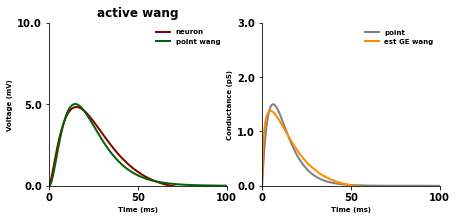

In [128]:
data = np.loadtxt('pair_EI_VClamp_REV80_active.dat')
v_rest = -70.
GL = 0.07;   
S = 1.66e-4; 
gl0 = np.mean(gl)
c0 = np.mean(c) 
V_neuron = data[0,:] - v_rest
time = np.arange(0,len(V_neuron))*0.1
V_li = np.zeros(len(V_neuron))
V_wang = np.zeros(len(V_neuron))
REV_E = 0. - v_rest
fE = 1.5e-3
NE = ((5./7.8)**(5./2.8)-(5./7.8)**(7.8/2.8))**(-1)
uE = np.exp(-time/7.8)-np.exp(-time/5.)


fig,ax = plt.subplots(1,2, figsize = (7,3))
dVdt = np.diff(V_neuron)/dt
dVdt = np.append(dVdt,0)
GE_est_li = S*(dVdt + GL*V_neuron)/(REV_E-V_neuron) 
GE_est_wang = (c0*dVdt + gl0*V_neuron)/(REV_E-V_neuron)


for i in range(len(V_neuron)-1):
    V_li[i+1] = V_li[i] - (GL*V_li[i] - fE*NE*uE[i]*1e-3*(REV_E - V_li[i])/S)*dt
    V_wang[i+1] = V_wang[i] - dt/c0*(gl0*V_wang[i] - fE*NE*uE[i]*1e-3*(REV_E-V_wang[i]))
    
plot_curve(ax[0],time[2000:]-200, V_neuron[2000:],label = 'neuron',color='darkred',
    ylabel='Voltage (mV)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,10], dy = 5.)
# plot_curve(ax[0],time,V_li,label = 'point li',color='steelblue',
#     ylabel='Voltage (mV)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,10], dy = 5., title='active li')
plot_curve(ax[0],time,V_wang ,label = 'point wang',color='darkgreen',
    ylabel='Voltage (mV)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,10], dy = 5., title='active wang')

# plot_curve(ax[1],time[2000:]-200, GE_est_li[2000:]*1e6,label = 'est GE li',color='black',
#     ylabel='Conductance (pS)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,2], dy = 1.)
plot_curve(ax[1],time,fE*NE*uE*1e3,label = 'point',color='grey',
    ylabel='Conductance (pS)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,3], dy = 1.)
plot_curve(ax[1],time[2000:]-200, GE_est_wang[2000:]*1e6,label = 'est GE wang',color='darkorange',
    ylabel='Conductance (pS)', xlabel='Time (ms)', xlim = [0,100], dx =50, ylim = [0,3], dy = 1.)


   
